In [2]:
import os
import math
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from generation_info import GenerationInfoHandler

mask_token_id = 9

/local/home/prisold/gidd/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Load data

base_dir = "/local/home/prisold/gidd/outputs/generation_info"
# num_dirs = len([name for name in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, name))]) # to use all combinations
num_dirs = 216 # to use first n combinations
combination_row_ids = [i for i in range(1, num_dirs + 1)] # if combination_0 also exists
# combination_row_ids = [i for i in range(num_dirs)] # if combination_0 does not exist
# combination_row_ids = [0] # to use combination_0

dir_path_dict = {}
meta_dict = {}
history_dict = {}
logits_dict = {}
marginals_dict = {}
change_events_table_dict = {}
denoise_config_dict = {}
combination_rows = []

for combination_row in combination_row_ids:
    dir_path = f"{base_dir}/combination_{combination_row}"
    meta, history, logits, marginals, change_events_table = GenerationInfoHandler.load_all(dir_path)
    dir_path_dict[combination_row] = dir_path
    meta_dict[combination_row] = meta
    history_dict[combination_row] = history
    logits_dict[combination_row] = logits
    marginals_dict[combination_row] = marginals
    change_events_table_dict[combination_row] = change_events_table
    denoise_config_dict[combination_row] = meta['sampling']['p_denoise']

    sampling_parameters = meta['sampling'].copy()
    if isinstance(sampling_parameters.get('p_denoise', None), dict):
        for k, v in sampling_parameters['p_denoise'].items():
            sampling_parameters[f'p_denoise_{k}'] = v
        del sampling_parameters['p_denoise']
    sampling_parameters['combination_row'] = combination_row
    combination_rows.append(sampling_parameters)

combinations_df = pd.DataFrame(combination_rows)

print(meta_dict[combination_row_ids[0]])

{'created_at': '2025-09-16 13:52:07 GMT', 'num_samples': 64, 'max_seq_len': 81, 'collect_history': True, 'collect_logits': True, 'collect_marginals': True, 'collect_change_events': True, 'sampling': {'strategy': 'gidd_prob_to_recover_data', 'score_mask_position': None, 'score_position_for_change': None, 'select_position': None, 'select_position_change': None, 'select_position_unmask': None, 'change_token': None, 'unmask_token': None, 'k': None, 'gumbel_noise_coefficient': None, 'self_correction': 'none', 'p_denoise': {'oracle': 'model', 'position_sampling': 'independent', 'position_metric': 'p_denoise', 'token_sampling': 'categorical', 'uniform_noise': 'none'}}, 'history_shape': [64, 83, 81], 'logits_shape': [64, 81, 81, 9], 'marginals_shapes': {'true_denoised_fraction': [82], 'denoised_fraction': [82], 'mask_fraction': [82], 'uniform_fraction': [82], 'p_zt_x_mean': [64, 82], 'p_zt_x_std': [64, 82], 'p_zt_x_min': [64, 82], 'p_zt_x_max': [64, 82], 'cell_accuracy': [64, 82], 'expected_ce

In [4]:
# Select combination to analyze

# oracle = 'perfect'
oracle = 'model'
# oracle = 'recurrence'
# oracle = 'model_and_recurrence'
# oracle = 'model_EMA'

# position_sampling = 'independent'
position_sampling = 'top_k'

# position_metric = 'p_denoise'
position_metric = 'confident_and_p_denoise'
# position_metric = 'confident_and_noisy'

# token_sampling = 'categorical'
token_sampling = 'change_max'
# token_sampling = 'max'

uniform_noise = 'none'
# uniform_noise = 'noise'
# uniform_noise = 'model'

combination_row = combinations_df.loc[(combinations_df['p_denoise_oracle'] == oracle) & (combinations_df['p_denoise_position_sampling'] == position_sampling) & (combinations_df['p_denoise_position_metric'] == position_metric) & (combinations_df['p_denoise_token_sampling'] == token_sampling) & (combinations_df['p_denoise_uniform_noise'] == uniform_noise)]['combination_row'].values[0]
print(f"selected combination row: {combination_row}")

sample_indices = [0, 1, 2, 3]
# sample_indices = [31, 44, 49, 59]
# sample_indices = [49,57,59,60]

selected combination row: 14


incorrect samples: [0, 17, 21, 24, 36, 37, 38, 43, 45]


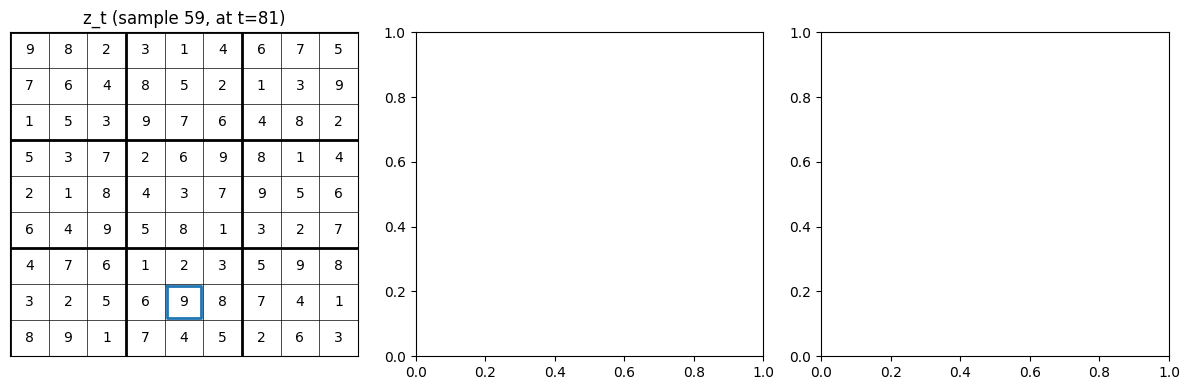

t=0: 902310070000050000000070400030260014000400900600000300076020090020008001800005000
t=81: 982314675764852139153976482537269814218437956649581327476123598325698741891745263


In [11]:
# Visualize z_t and logits/probs for selected sample, time step, and position
from matplotlib.patches import Rectangle
def visualize_state(sample, time_step, position, logits, history, show_logits=True, show_probs=True):
    position = (position[0] - 1, position[1] - 1) # convert to 0-indexed
    solution = history[:, -1, :]
    history = history[:, :-1, :]
    seq_len = history.shape[-1]
    vocab_size = logits.shape[-1]
    z_t = history[sample, time_step]

    rows = math.ceil(math.sqrt(seq_len))
    cols = seq_len // rows + (1 if seq_len % rows != 0 else 0)
    flat_idx = position[0] * cols + position[1]

    # ---- Figure 1: token grid ----
    grid = np.full((rows, cols), -1, dtype=np.int32)
    upto = min(seq_len, rows * cols)
    grid.flat[:upto] = z_t[:upto]

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))
    ax1.set_title(f"z_t (sample {sample}, at t={time_step})")
    ax1.set_xticks(np.arange(-0.5, cols, 1), minor=True)
    ax1.set_yticks(np.arange(-0.5, rows, 1), minor=True)
    ax1.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)

    # overlay token values
    for i in range(upto):
        r, c = divmod(i, cols)
        token = int(z_t[i])
        token_str = str(token + 1) if token != mask_token_id else ""
        ax1.text(c, r, token_str, ha="center", va="center")
    
    # highlight cells that will change in next step by filling cell with light red color
    will_change_indices = []
    if time_step < history.shape[1] - 1:
        diff_mask = z_t != history[sample, time_step + 1]
        changes = np.nonzero(diff_mask)
        if len(changes) > 0:
            will_change_indices = changes[0].tolist()
    for i in will_change_indices:
        if i >= upto:
            continue
        rc_r, rc_c = divmod(i, cols)
        rect = Rectangle((rc_c - 0.45, rc_r - 0.45), 0.9, 0.9, fill=False, linewidth=2, edgecolor="orange")
        ax1.add_patch(rect)
    
    # fill incorrect cells
    incorrect_mask = (z_t != solution[sample]) & (z_t != mask_token_id)
    incorrect_indices = np.flatnonzero(incorrect_mask)
    for i in incorrect_indices:
        if i >= upto:
            continue
        r, c = divmod(i, cols)
        ax1.add_patch(Rectangle(
            (c - 0.5, r - 0.5), 1, 1,
            facecolor="#f8d7da",  # light red
            edgecolor="none",
            alpha=0.8,
            zorder=0.1  # behind text/selection, ahead of background
        ))

    # highlight selected cell
    sel_r, sel_c = divmod(flat_idx, cols)
    ax1.plot([sel_c-0.45, sel_c+0.45, sel_c+0.45, sel_c-0.45, sel_c-0.45],
             [sel_r-0.45, sel_r-0.45, sel_r+0.45, sel_r+0.45, sel_r-0.45],
             linewidth=2)

    # thin grid lines
    ax1.grid(which="minor", color="black", linewidth=0.5)

    # thick box lines
    if rows == cols:
        box = int(math.sqrt(rows))
        for r in range(0, rows, box):
            ax1.axhline(r-0.5, color="black", linewidth=2)
        for c in range(0, cols, box):
            ax1.axvline(c-0.5, color="black", linewidth=2)
    
    ax1.set_xlim(-0.5, cols - 0.5)
    ax1.set_ylim(rows - 0.5, -0.5)

    # ---- Figure 2: logits ----
    if show_logits and time_step < logits.shape[1]:
        logits_vec = logits[sample, time_step, flat_idx].to(torch.float32).numpy().copy()

        ax2.set_title(f"Logits at position ({position[0]}, {position[1]})")
        ax2.set_xlabel("Token")
        # ax2.set_ylabel("Logit")

        x = np.arange(vocab_size)
        ax2.bar(x, logits_vec)
        if vocab_size <= 50:
            ax2.set_xticks(x)
            ax2.set_xticklabels([str(v + 1) for v in range(vocab_size)], rotation=90)
    
    # ---- Figure 3: probs ----
    if show_probs and time_step < logits.shape[1]:
        probs_vec = logits[sample, time_step, flat_idx].softmax(dim=-1).to(torch.float32).numpy().copy()
        ax3.set_title(f"Confidence at position ({position[0]}, {position[1]})")
        ax3.set_xlabel("Token")
        ax3.set_ylabel("Confidence")

        x = np.arange(vocab_size)
        ax3.bar(x, probs_vec)
        if vocab_size <= 50:
            ax3.set_xticks(x)
            ax3.set_xticklabels([str(v + 1) for v in range(vocab_size)], rotation=90)

    plt.tight_layout()
    plt.show()

# incorrect samples:
# 0 (Unique Rectangle Type 1),
# # # 13(XY-wing, XY-chain, Almost Locked Set),
# 17 (Color Wing, XY-chain, Color Trap),
# 21 (Color Wing),
# 24 (not solvable by sudokusolver.app),
# # 33 (XY-wing, Color Wrap, XY-chain),
# # 36 (XY-wing, Almost Locked Set, XYZ-wing, Color Wrap),
# 37 (not solvable by sudokusolver.app),
# 38 (XY-wing, Almost Locked Set, Color Wing, Color Trap, XY-chain, Swordfish),
# # 40 (Finned X-wing),
# 43 (Finned X-wing, Almost Locked Set),
# 45 (XY-wing, XYZ-wing),
# # # 47 (XY-wing, XY-chain),
# # 59 (multiple solutions!!!!),

# potentially actually hard techniques: Color Wing, Color Trap, Swordfish,Unique Rectangle Type 1, not solvables
sample = 59
time_step = 81
# position = (6, 8) # 1-indexed
# position = (2, 1) # 1-indexed
# position = (8, 5) # 1-indexed
position = (4, 3) # 1-indexed

position = (4, 6) # 1-indexed
position = (4, 2) # 1-indexed
position = (9, 6) # 1-indexed
position = (7, 6) # 1-indexed
position = (3, 1) # 1-indexed
position = (1, 6) # 1-indexed
position = (6, 8) # 1-indexed
position = (4, 7) # 1-indexed
position = (6, 7) # 1-indexed
position = (9, 7) # 1-indexed
position = (5, 3) # 1-indexed
position = (8, 5) # 1-indexed

show_logits = True
show_probs = True
print(f'incorrect samples: {(history_dict[combination_row][:, -1, :] != history_dict[combination_row][:, -2, :]).any(-1).nonzero().squeeze(-1).tolist()}')
visualize_state(sample, time_step, position, logits_dict[combination_row], history_dict[combination_row][:, :, :], show_logits=show_logits, show_probs=show_probs)
print(f't=0: {''.join([str(d + 1) if d != 9 else '0' for d in history_dict[combination_row][sample, 0, :].tolist()])}')
print(f't={time_step}: {''.join([str(d + 1) if d != 9 else '0' for d in history_dict[combination_row][sample, time_step, :].tolist()])}')

In [ ]:
# Analyze human strategies required
from dokusan import solvers
from dokusan.boards import BoxSize, Sudoku
from datasets import load_from_disk

def find_required_strategies(puzzles):
    strategies_required = {}
    strategies_required['unsolvable'] = 0
    for puzzle in puzzles:
        sudoku = Sudoku.from_list(puzzle, box_size=BoxSize(3, 3))
        strategies_required_for_sudoku = set()
        try:
            for step in solvers.steps(sudoku):
                strategies_required_for_sudoku.add(step.combination.name)
        except:
            # Puzzle is unsolvable with this solver
            strategies_required['unsolvable'] = strategies_required.get('unsolvable', 0) + 1
            continue
        for strategy in strategies_required_for_sudoku:
            strategies_required[strategy] = strategies_required.get(strategy, 0) + 1
    return strategies_required

test_puzzles = history_dict[combination_row][:, 0, :].view((-1, 9, 9)).tolist()

ds_easy = load_from_disk("/local/home/prisold/gidd/gidd/datasets/sudoku_shah/easy/test")
# ds_easy = ds_easy[:1000]
easy_puzzles = [np.array([int(c) for c in puzzle_str]).reshape((9, 9)) for puzzle_str in ds_easy['puzzle']]

required_strategies_test_puzzles = find_required_strategies(test_puzzles)
required_strategies_easy_puzzles = find_required_strategies(easy_puzzles)

print(f"Num test puzzles: {len(test_puzzles)}, required strategies: {required_strategies_test_puzzles}")
# Num test puzzles: 64, required strategies: {'unsolvable': 64}
print(f"Num easy puzzles: {len(easy_puzzles)}, required strategies: {required_strategies_easy_puzzles}")
# Num easy puzzles: 99999, required strategies: {'unsolvable': 0, 'Hidden Single': 98290, 'Lone Single': 99999, 'Bulk Pencil Marking': 99999, 'Naked Triplet': 5981, 'Naked Pair': 26230, 'Locked Candidate': 12906, 'XY Wing': 4080, 'Unique Rectangle': 1796}

Num easy puzzles: 99999, required strategies: {'unsolvable': 0, 'Hidden Single': 98290, 'Lone Single': 99999, 'Bulk Pencil Marking': 99999, 'Naked Triplet': 5981, 'Naked Pair': 26230, 'Locked Candidate': 12906, 'XY Wing': 4080, 'Unique Rectangle': 1796}
Num test puzzles: 64, required strategies: {'unsolvable': 64}


In [33]:
# Plot total accuracy
skip = True
if not skip:
    fig, ax = plt.subplots(figsize=(10, 6))

    for current_combination_row in combination_row_ids:
        marginals = marginals_dict[current_combination_row]
        total_accuracy = marginals['total_accuracy'].cpu().numpy()  # shape (num_denoising_steps,)
        label = ', '.join([f'{key}={value}' for key, value in denoise_config_dict[current_combination_row].items()])
        ax.plot(total_accuracy, label=label)

    ax.set_xlabel('Timestep')
    ax.set_ylabel('Total Accuracy')
    ax.set_title('Total Accuracy Over Time')
    ax.legend()
    plt.tight_layout()


In [5]:
# Create df containing solved/not solved for combinations (cols) and samples (rows)
solved_cols = {}
for current_combination_row, marginals in marginals_dict.items():
    solved = marginals['cell_accuracy'][:, -1].cpu().numpy() == 1.0
    solved_cols[current_combination_row] = solved

solved_df = pd.DataFrame(solved_cols).T # shape (num_combinations, num_samples)
num_seeds = 3
num_combinations = solved_df.shape[0]
num_combinations_per_seed = solved_df.shape[0] // num_seeds
# aggregate combinations over the seeds
solved_df = solved_df.groupby(by = lambda x: x % (num_combinations_per_seed)).sum() # shape (num unique combinations, num_samples)

solved_count = solved_df.sum(axis=0)
print(f'samples not solved by any combnation: {solved_count[solved_count == 0].index.tolist()}')

solved_count_by_sample = {}
for sample, solved_counts_by_combination in solved_df.items():
    solved_at_least_once = solved_counts_by_combination[solved_counts_by_combination > 0]
    solved_count_by_sample[sample] = {'num_unique_combinations_solved': len(solved_at_least_once), 'solved_counts_by_combination': solved_at_least_once.to_dict()}

solved_count_by_sample = dict(sorted(solved_count_by_sample.items(), key=lambda item: item[1]['num_unique_combinations_solved']))
for i, (sample, info) in enumerate(solved_count_by_sample.items()):
    print(f'sample {sample} was solved by {info["num_unique_combinations_solved"]} unique combinations: {info["solved_counts_by_combination"]}')
    if i == 10:
        break

# Greedy set cover: find smallest set of combinations covering all samples
remaining_samples = set(solved_df.columns)
selected_combinations = []
solved_df_bool = solved_df > 0

while remaining_samples:
    # Find the combination that covers the most remaining samples
    best_comb = None
    best_cover = set()
    for comb in solved_df_bool.index:
        covered = set(solved_df_bool.columns[solved_df_bool.loc[comb] & solved_df_bool.columns.isin(remaining_samples)])
        if len(covered) > len(best_cover):
            best_comb = comb
            best_cover = covered
    if not best_cover:
        print("No combination can cover remaining samples:", remaining_samples)
        break
    selected_combinations.append(best_comb)
    remaining_samples -= best_cover

print(f"Smallest set of unique combinations covering all samples: {selected_combinations}")
print(solved_df.T[49].values)
print(len(solved_df.T[49].values))
print(sum(solved_df.T[49].values))
print(sum(solved_df.T[49].values) / num_seeds)
print(sum(solved_df.T[49].values) / num_seeds / len(solved_df.T[49].values))



samples not solved by any combnation: []
sample 47 was solved by 16 unique combinations: {13: 2, 14: 2, 15: 2, 16: 2, 17: 2, 18: 2, 27: 1, 46: 1, 49: 1, 50: 1, 51: 1, 52: 1, 53: 1, 54: 1, 62: 1, 63: 1}
sample 37 was solved by 18 unique combinations: {10: 1, 11: 1, 12: 1, 13: 1, 16: 1, 28: 1, 29: 1, 30: 1, 46: 1, 47: 1, 48: 1, 49: 1, 52: 1, 62: 1, 63: 1, 64: 1, 65: 1, 66: 1}
sample 23 was solved by 24 unique combinations: {0: 3, 13: 3, 14: 3, 15: 3, 16: 3, 17: 3, 18: 3, 31: 2, 32: 2, 33: 2, 34: 2, 35: 2, 36: 2, 49: 3, 50: 3, 51: 3, 52: 3, 53: 3, 54: 3, 67: 3, 68: 3, 69: 3, 70: 3, 71: 3}
sample 16 was solved by 25 unique combinations: {0: 2, 13: 2, 14: 2, 15: 2, 16: 2, 17: 2, 18: 2, 31: 2, 32: 2, 33: 2, 34: 2, 35: 2, 36: 2, 49: 1, 50: 1, 51: 1, 52: 1, 53: 1, 54: 1, 63: 1, 67: 2, 68: 2, 69: 2, 70: 2, 71: 2}
sample 38 was solved by 25 unique combinations: {5: 1, 6: 1, 10: 1, 11: 1, 12: 1, 28: 1, 29: 1, 30: 1, 43: 1, 45: 1, 46: 1, 47: 1, 48: 1, 49: 1, 50: 1, 51: 1, 52: 1, 53: 1, 54: 1, 61: 

In [15]:
# check if there are samples where accuracy reached 1 but ended with less than 1

for current_combination_row, marginals in marginals_dict.items():
    cell_accuracy = marginals['cell_accuracy'].cpu().numpy()
    earliest_reach_1 = np.argmax(cell_accuracy == 1, axis=1)
    final_accuracy_is_1 = cell_accuracy[:, -1] == 1
    problematic_samples = ((earliest_reach_1 > 0) & (~final_accuracy_is_1)).nonzero()[0].tolist()
    if len(problematic_samples) > 0:
        samples_str = 'sample' if len(problematic_samples) == 1 else 'samples'
        print(f"Found {len(problematic_samples)} problematic {samples_str} in combination {current_combination_row}, {samples_str}: {problematic_samples}, steps: {earliest_reach_1[problematic_samples]}. ({list(meta_dict[current_combination_row]['sampling']['p_denoise'].values())})")


In [ ]:
from gidd.eval.sudoku_correctness import print_sudoku
# Visualize the first state of the selected samples' histories
step = 0
history = history_dict[combination_row]
for sample in sample_indices:
    puzzle = history[sample][step].numpy().reshape(9, 9)
    row_sets = [set(row) for row in puzzle]
    col_sets = [set(col) for col in puzzle.T]
    box_size = int(len(puzzle) ** 0.5)
    box_sets =[set(puzzle[i*box_size:(i+1)*box_size, j*box_size:(j+1)*box_size].flatten()) for i in range(box_size) for j in range(box_size)]
    score = 0
    for curr_set in row_sets + col_sets + box_sets:
        for i in range(len(puzzle)):
            if i in curr_set:
                score += 1
    print(f"set score: {score} of max {3 * 9 * 9}")
    print_sudoku(puzzle, mask_token_id)


set score: 75 of max 243
. . .  . . .  5 6 0  
. 6 0  . 2 .  . . .  
5 . .  . 7 .  . . .  

. . .  . 3 8  . . 4  
. . .  4 1 .  7 . .  
. 0 3  . . 2  . 5 .  

. 3 2  . . .  . 4 .  
. 7 6  . . .  2 . .  
. . .  . . .  . 0 .  

set score: 72 of max 243
. 4 2  . . 8  . 7 .  
. . .  . . 6  . 8 .  
. . 6  . 0 .  2 . .  

. . .  . . .  . 0 .  
. . .  . 3 .  . 4 1  
5 . .  4 . 2  . . .  

. 7 .  . . .  . 1 4  
2 . .  0 6 .  . . 5  
. . .  . . 5  . . .  

set score: 75 of max 243
. . .  . 6 .  . . .  
1 . .  . . 2  . . 6  
. 3 .  . 5 .  0 7 .  

. 4 .  0 . .  . . .  
. . 5  . 3 .  . 6 .  
0 . .  . . .  8 . 1  

. 8 .  2 . .  . . 7  
. . .  4 . .  3 . .  
. 0 .  . . 3  1 . 8  

set score: 78 of max 243
8 . 1  2 0 .  . 6 .  
. . .  . 4 .  . . .  
. . .  . 6 .  3 . .  

. 2 .  1 5 .  . 0 3  
. . .  3 . .  8 . .  
5 . .  . . .  2 . .  

. 6 5  . 1 .  . 8 .  
. 1 .  . . 7  . . 0  
7 . .  . . 4  . . .  



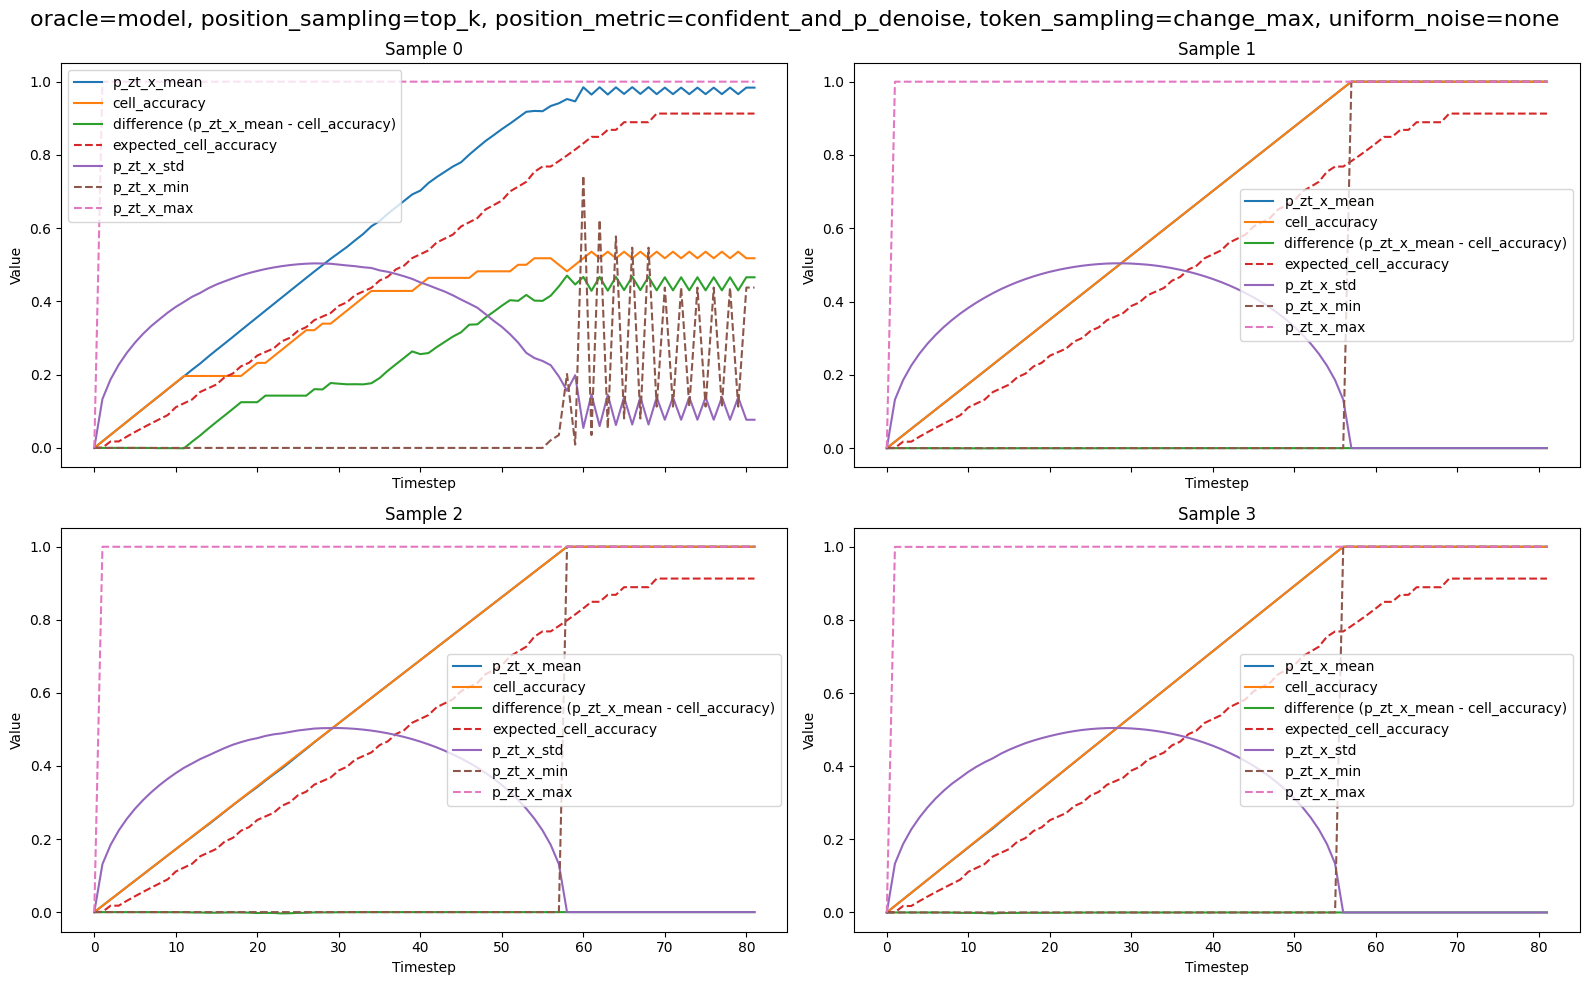

In [6]:
# Plot marginals
marginals = marginals_dict[combination_row]
p_zt_x_mean = marginals['p_zt_x_mean'].cpu().numpy()  # shape: (num_samples, num_steps)
p_zt_x_std = marginals['p_zt_x_std'].cpu().numpy()    # shape: (num_samples, num_steps)
p_zt_x_min = marginals['p_zt_x_min'].cpu().numpy()    # shape: (num_samples, num_steps)
p_zt_x_max = marginals['p_zt_x_max'].cpu().numpy()    # shape: (num_samples, num_steps)
cell_accuracy = marginals['cell_accuracy'].cpu().numpy()  # shape: (num_samples, num_steps)
expected_cell_accuracy = marginals['expected_cell_accuracy'].cpu().numpy()  # shape: (num_steps)
difference = p_zt_x_mean - cell_accuracy

fig, axs = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
for ax, idx in zip(axs.flatten(), sample_indices):
    ax.plot(p_zt_x_mean[idx], label='p_zt_x_mean')
    ax.plot(cell_accuracy[idx], label='cell_accuracy')
    ax.plot(difference[idx], label='difference (p_zt_x_mean - cell_accuracy)')
    ax.plot(expected_cell_accuracy, label='expected_cell_accuracy', linestyle='--')
    ax.plot(p_zt_x_std[idx], label='p_zt_x_std')
    ax.plot(p_zt_x_min[idx], label='p_zt_x_min', linestyle='--')
    ax.plot(p_zt_x_max[idx], label='p_zt_x_max', linestyle='--')
    ax.set_title(f'Sample {idx}')
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Value')
    ax.legend()
plt.suptitle(', '.join([f'{key}={value}' for key, value in denoise_config_dict[combination_row].items()]), fontsize=16)
plt.tight_layout()

plt.savefig(dir_path_dict[combination_row] + '/marginals.png')

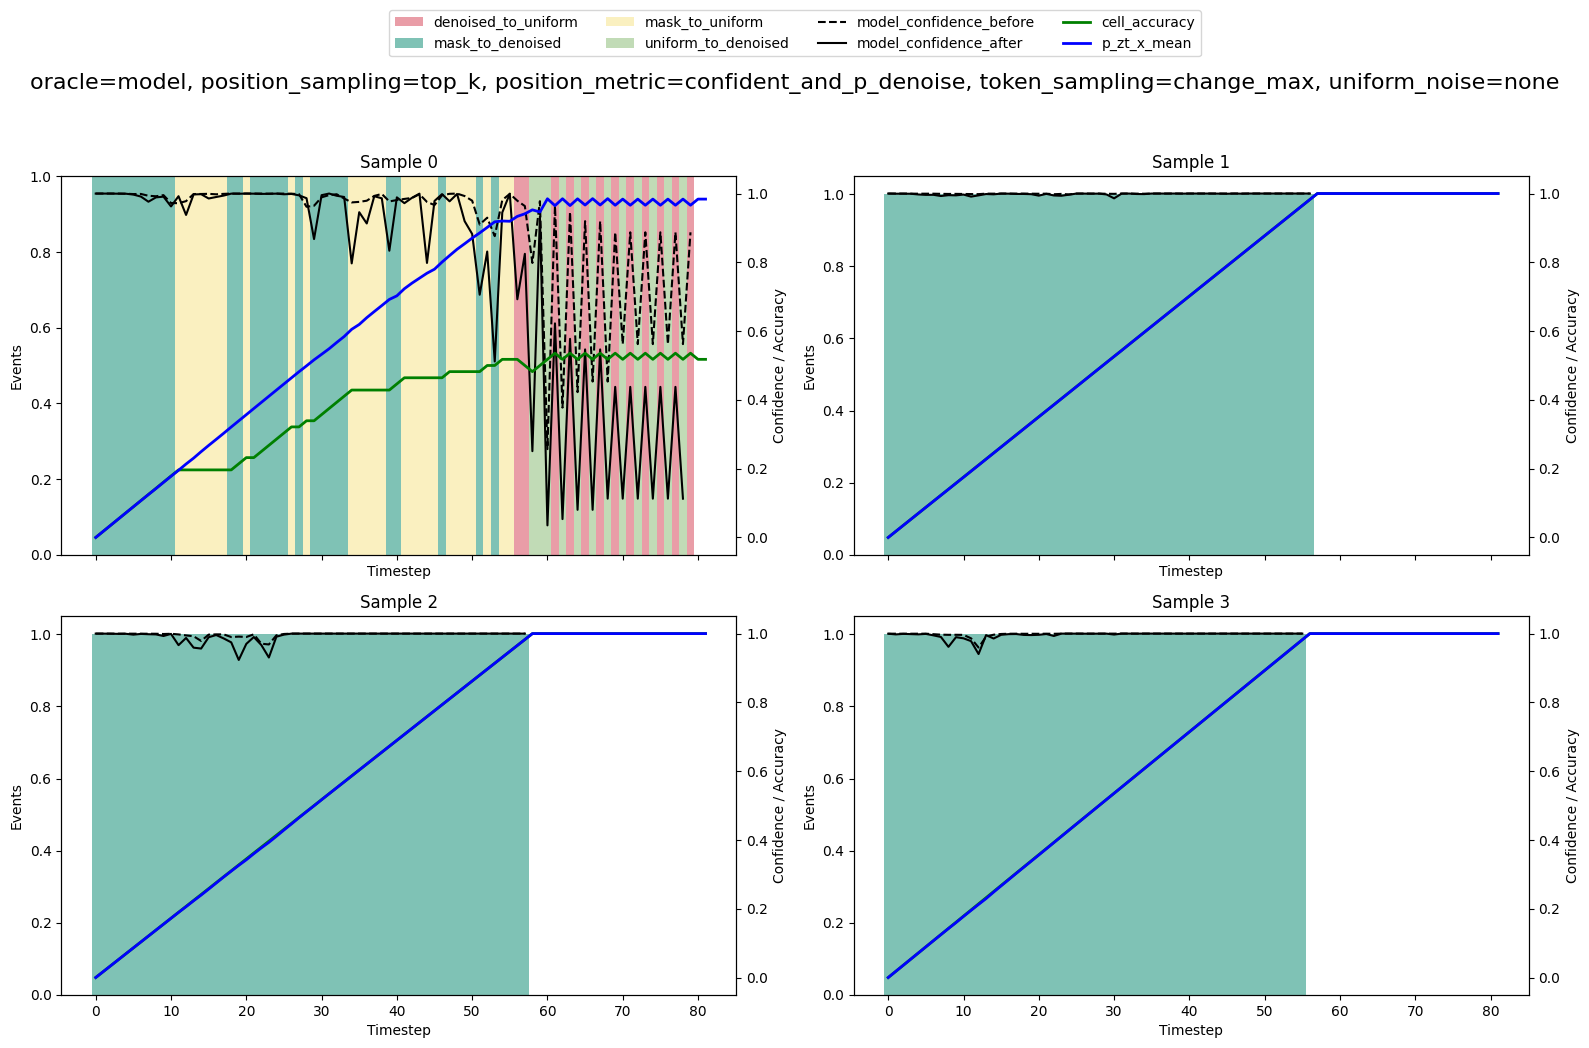

In [7]:
# Plot change events

# Define consistent color scheme for event types
event_colors = {
    'mask_to_denoised': '#00876c',
    'uniform_to_denoised': '#85b96f',
    'mask_to_uniform': '#f7e382',
    'uniform_to_uniform': '#f19452',
    'denoised_to_uniform': '#d43d51'
}
#00876c
#88c580
#ffff9d
#f7a258
#d43d51

n = 2
# k = 0
# sample_indices = range(n**2 * k, n**2 * (k + 1))
fig, axs = plt.subplots(n, n, figsize=(16, 10), sharex=True)

# Collect handles and labels for one global legend
all_handles, all_labels = [], []

for ax, idx in zip(axs.flatten(), sample_indices):
    # Filter change events for the current sample
    sample_events = change_events_table[change_events_table['sample'] == idx]

    # Plot number of events per step, colored by event_type
    event_counts = sample_events.groupby(['step', 'event_type']).size().unstack(fill_value=0)
    bottom = None
    for event_type in event_counts.columns:
        color = event_colors.get(event_type, None)
        bar = ax.bar(event_counts.index, event_counts[event_type], bottom=bottom,
                     alpha=0.5, width=1, color=color, label=event_type)
        if bottom is None:
            bottom = event_counts[event_type]
        else:
            bottom += event_counts[event_type]

        # Collect legend entries only once
        if event_type not in all_labels:
            all_handles.append(bar[0])
            all_labels.append(event_type)

    # Secondary y-axis
    ax2 = ax.twinx()

    mean_conf_before = sample_events.groupby('step')['model_confidence'].mean()
    line1, = ax2.plot(mean_conf_before.index, mean_conf_before.values,
                      color='black', linestyle='--', label='model_confidence_before')
    mean_conf_after = sample_events.groupby('step')['model_confidence_after'].mean()
    line2, = ax2.plot(mean_conf_after.index, mean_conf_after.values,
                      color='black', label='model_confidence_after')

    timesteps = range(len(cell_accuracy[idx]))
    line3, = ax2.plot(timesteps, cell_accuracy[idx], color='green', label='cell_accuracy', linewidth=2)
    line4, = ax2.plot(timesteps, p_zt_x_mean[idx], color='blue', label='p_zt_x_mean', linewidth=2)

    # Collect line labels only once
    for line, label in zip([line1, line2, line3, line4],
                           ['model_confidence_before', 'model_confidence_after',
                            'cell_accuracy', 'p_zt_x_mean']):
        if label not in all_labels:
            all_handles.append(line)
            all_labels.append(label)

    ax.set_title(f'Sample {idx}')
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Events')
    ax2.set_ylabel('Confidence / Accuracy')

# Shared legend for all subplots
fig.legend(all_handles, all_labels, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.05))

plt.suptitle(', '.join([f'{key}={value}' for key, value in denoise_config_dict[combination_row].items()]), fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave space for suptitle + legend

plt.savefig(dir_path_dict[combination_row] + '/change_events.png')


TODO: maybe consider time dimension as well
3838
3838
[0.99999928 0.99999952 0.99999869 0.99999702 0.99999785 0.99999905
 0.99999905 0.99999869 0.99999881 0.99999821]
[0.99999654 0.99999332 0.9999913  0.99999094 0.99999607 0.99999654
 0.99999332 0.99998975 0.99998522 0.99999332]
[1 1 1 1 1 1 1 1 1 1]
Correlation between model confidence and accuracy: 0.266 (p=4.39e-63)
Correlation between model confidence after and accuracy: nan (p=nan)


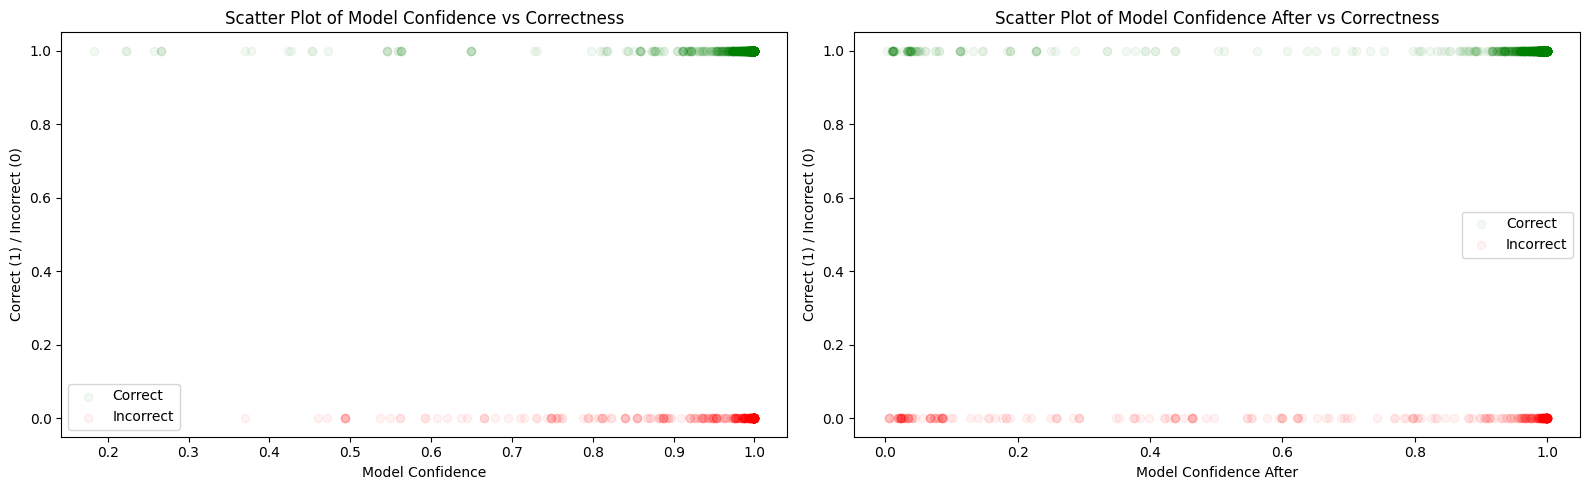

In [8]:
# Plot change events scatter plots of confidence vs accuracy

change_events_table = change_events_table_dict[combination_row]

# Optionally filter by step range
step_min_threshold = 0
step_max_threshold = 100
change_events_table = change_events_table[(change_events_table['step'] >= step_min_threshold) & (change_events_table['step'] < step_max_threshold)]

confidence_when_correct = change_events_table[(change_events_table['event_type'] == 'mask_to_denoised') | (change_events_table['event_type'] == 'uniform_to_denoised')]['model_confidence'].tolist()
confidence_when_incorrect = change_events_table[(change_events_table['event_type'] != 'mask_to_denoised') & (change_events_table['event_type'] != 'uniform_to_denoised')]['model_confidence'].tolist()
confidence_after_when_correct = change_events_table[(change_events_table['event_type'] == 'mask_to_denoised') | (change_events_table['event_type'] == 'uniform_to_denoised')]['model_confidence_after'].tolist()
confidence_after_when_incorrect = change_events_table[(change_events_table['event_type'] != 'mask_to_denoised') & (change_events_table['event_type'] != 'uniform_to_denoised')]['model_confidence_after'].tolist()


fig, axs = plt.subplots(1, 2, figsize=(16, 5))

alpha = 0.05
# alpha = 20 / (len(confidence_when_correct) + len(confidence_when_incorrect))

# Plot correct events
axs[0].scatter(confidence_when_correct, [1] * len(confidence_when_correct), color='green', label='Correct', alpha=alpha)
# Plot incorrect events
axs[0].scatter(confidence_when_incorrect, [0] * len(confidence_when_incorrect), color='red', label='Incorrect', alpha=alpha)

axs[0].set_xlabel('Model Confidence')
axs[0].set_ylabel('Correct (1) / Incorrect (0)')
axs[0].set_title('Scatter Plot of Model Confidence vs Correctness')
axs[0].legend()

axs[1].scatter(confidence_after_when_correct, [1] * len(confidence_after_when_correct), color='green', label='Correct', alpha=alpha)
axs[1].scatter(confidence_after_when_incorrect, [0] * len(confidence_after_when_incorrect), color='red', label='Incorrect', alpha=alpha)

axs[1].set_xlabel('Model Confidence After')
axs[1].set_ylabel('Correct (1) / Incorrect (0)')
axs[1].set_title('Scatter Plot of Model Confidence After vs Correctness')
axs[1].legend()

plt.tight_layout()
print("TODO: maybe consider time dimension as well")

# Compute correlation between confidence and accuracy
import scipy.stats

all_confidences = change_events_table['model_confidence'].to_numpy()
all_confidences_after = change_events_table['model_confidence_after'].to_numpy()
all_correct = ((change_events_table['event_type'] == 'mask_to_denoised') | (change_events_table['event_type'] == 'uniform_to_denoised')).astype(int).to_numpy()

corr_before, pval_before = scipy.stats.pearsonr(all_confidences, all_correct)
corr_after, pval_after = scipy.stats.pearsonr(all_confidences_after, all_correct)
print(len(all_confidences))
print(len(all_confidences_after))
print(all_confidences[-10:])
print(all_confidences_after[-10:])
print(all_correct[-10:])

print(f"Correlation between model confidence and accuracy: {corr_before:.3f} (p={pval_before:.3g})")
print(f"Correlation between model confidence after and accuracy: {corr_after:.3f} (p={pval_after:.3g})")

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


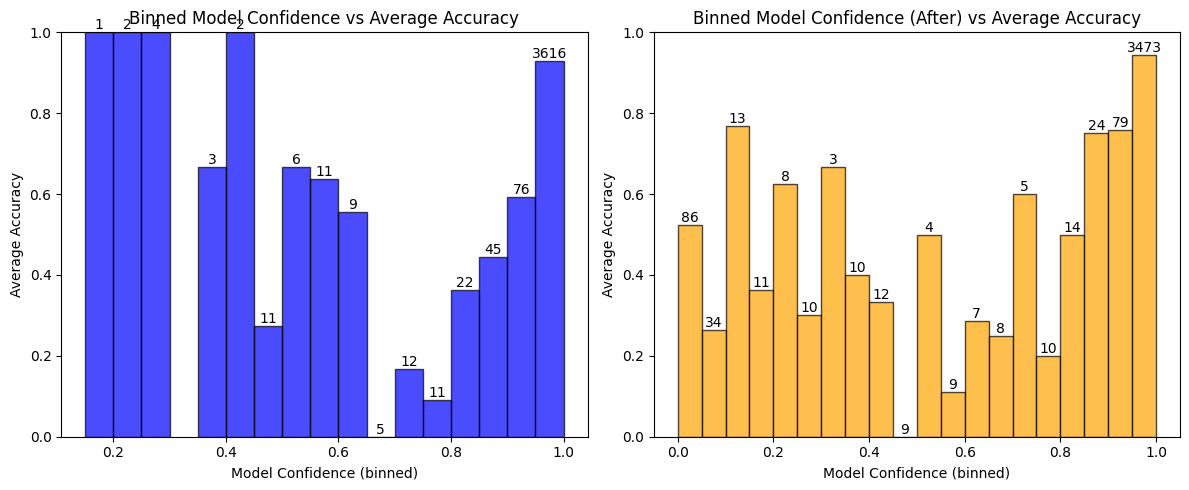

In [9]:
# Bin the model confidence values and plot average accuracy per bin

change_events_table = change_events_table_dict[combination_row]

# Optionally filter by step range
step_min_threshold = 0
step_max_threshold = 100
change_events_table = change_events_table[(change_events_table['step'] >= step_min_threshold) & (change_events_table['step'] < step_max_threshold)]

# Combine all events for binning
all_confidences = change_events_table['model_confidence'].to_numpy()
all_confidences_after = change_events_table['model_confidence_after'].to_numpy()
all_correct = ((change_events_table['event_type'] == 'mask_to_denoised') | (change_events_table['event_type'] == 'uniform_to_denoised')).astype(int).to_numpy()

# Define bins
num_bins = 20
bins = np.linspace(0, 1, num_bins + 1)
bin_indices = np.digitize(all_confidences, bins) - 1  # bins are 0-indexed
bin_indices_after = np.digitize(all_confidences_after, bins) - 1  # bins are 0-indexed

# Compute average accuracy per bin
bin_centers = 0.5 * (bins[:-1] + bins[1:])
avg_accuracy_per_bin = [all_correct[bin_indices == i].mean() if np.any(bin_indices == i) else np.nan for i in range(num_bins)]
avg_accuracy_per_bin_after = [all_correct[bin_indices_after == i].mean() if np.any(bin_indices_after == i) else np.nan for i in range(num_bins)]
counts_per_bin = [np.sum(bin_indices == i) for i in range(num_bins)]
counts_per_bin_after = [np.sum(bin_indices_after == i) for i in range(num_bins)]

# Plot binned average accuracy
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
bars00 = axs[0].bar(bin_centers, avg_accuracy_per_bin, width=(bins[1] - bins[0]), alpha=0.7, color='blue', edgecolor='black')
axs[0].set_xlabel('Model Confidence (binned)')
axs[0].set_ylabel('Average Accuracy')
axs[0].set_title('Binned Model Confidence vs Average Accuracy')
axs[0].set_ylim(0, 1)
for bar, count in zip(bars00, counts_per_bin):
    axs[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(count), ha='center', va='bottom', fontsize=10)

bars10 = axs[1].bar(bin_centers, avg_accuracy_per_bin_after, width=(bins[1] - bins[0]), alpha=0.7, color='orange', edgecolor='black')
axs[1].set_xlabel('Model Confidence (binned)')
axs[1].set_ylabel('Average Accuracy')
axs[1].set_title('Binned Model Confidence (After) vs Average Accuracy')
axs[1].set_ylim(0, 1)
for bar, count in zip(bars10, counts_per_bin_after):
    axs[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(count), ha='center', va='bottom', fontsize=10)

plt.tight_layout()

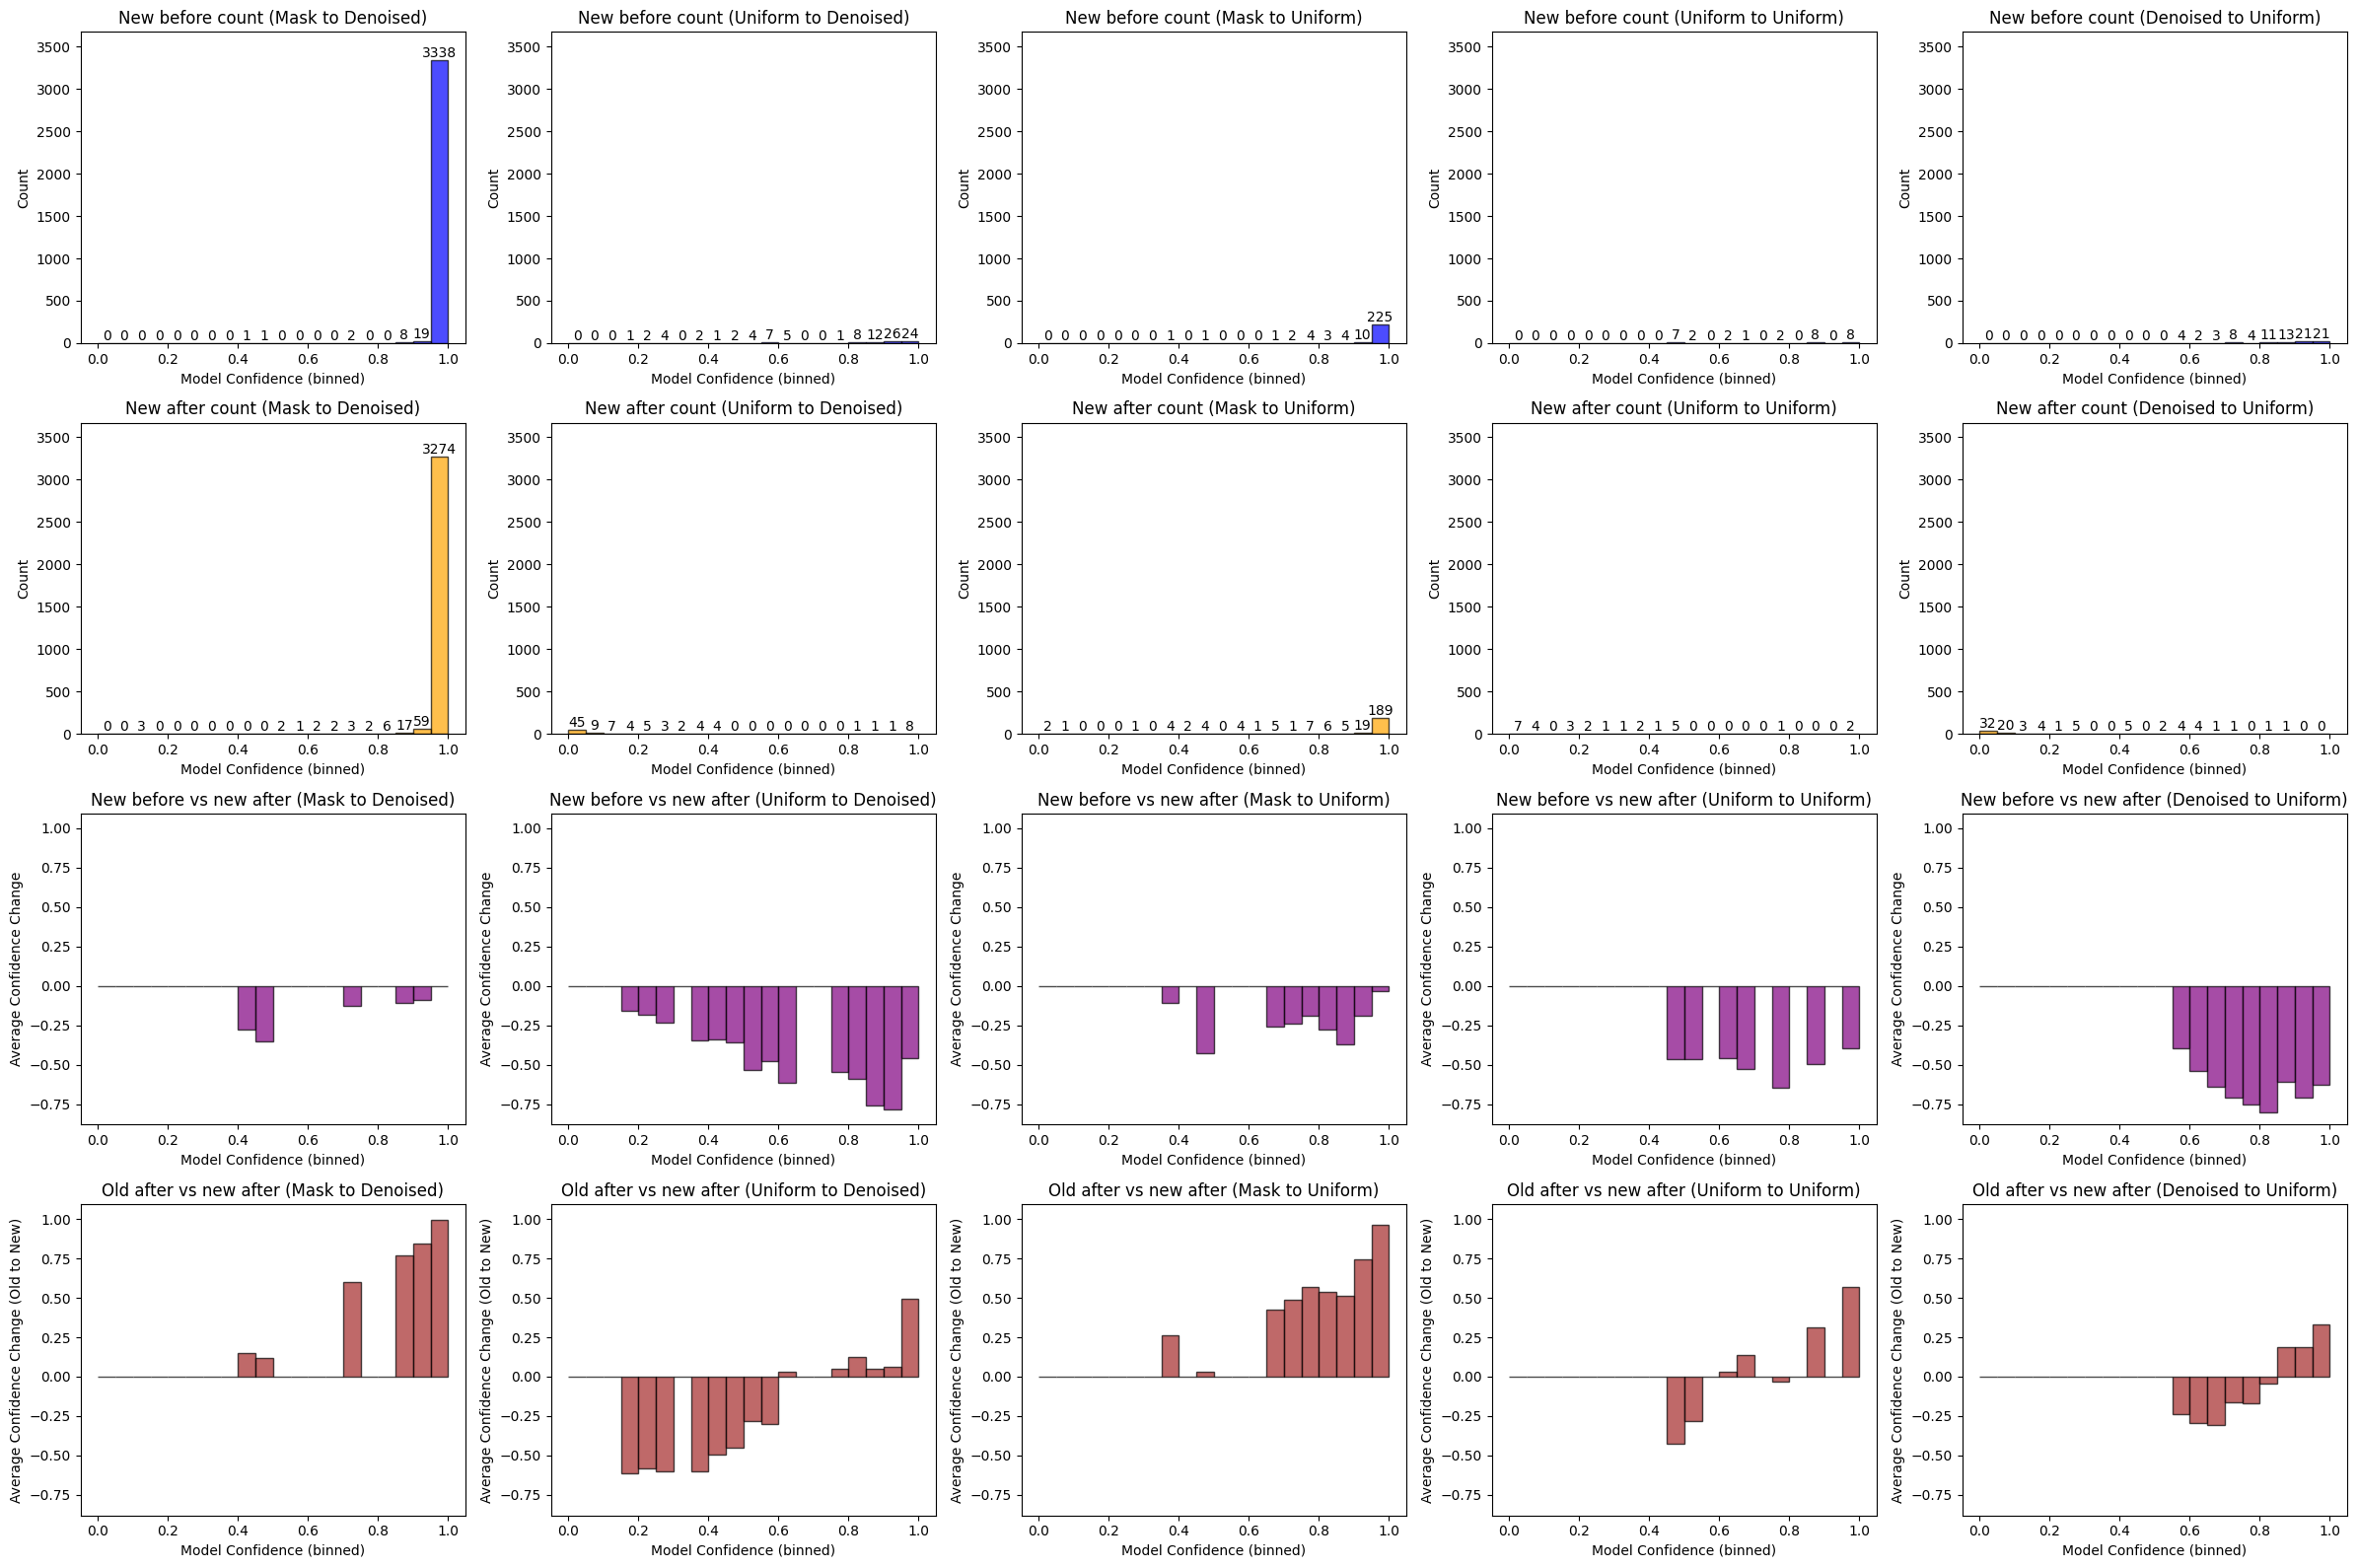

In [10]:
# look at m -> x and u -> x, plot counts per confidence bin (before and after)
change_events_table = change_events_table_dict[combination_row]
mask_to_denoised_confidence = change_events_table[change_events_table['event_type'] == 'mask_to_denoised']['model_confidence']
mask_to_denoised_confidence_after = change_events_table[change_events_table['event_type'] == 'mask_to_denoised']['model_confidence_after']
mask_to_denoised_old_value_confidence = change_events_table[change_events_table['event_type'] == 'mask_to_denoised']['old_value_confidence']
mask_to_denoised_before_after_diff = mask_to_denoised_confidence_after - mask_to_denoised_confidence
mask_to_denoised_old_new_diff = mask_to_denoised_confidence_after - mask_to_denoised_old_value_confidence
uniform_to_denoised_confidence = change_events_table[change_events_table['event_type'] == 'uniform_to_denoised']['model_confidence']
uniform_to_denoised_confidence_after = change_events_table[change_events_table['event_type'] == 'uniform_to_denoised']['model_confidence_after']
uniform_to_denoised_old_value_confidence = change_events_table[change_events_table['event_type'] == 'uniform_to_denoised']['old_value_confidence']
uniform_to_denoised_before_after_diff = uniform_to_denoised_confidence_after - uniform_to_denoised_confidence
uniform_to_denoised_old_new_diff = uniform_to_denoised_confidence_after - uniform_to_denoised_old_value_confidence
mask_to_uniform_confidence = change_events_table[change_events_table['event_type'] == 'mask_to_uniform']['model_confidence']
mask_to_uniform_confidence_after = change_events_table[change_events_table['event_type'] == 'mask_to_uniform']['model_confidence_after']
mask_to_uniform_old_value_confidence = change_events_table[change_events_table['event_type'] == 'mask_to_uniform']['old_value_confidence']
mask_to_uniform_before_after_diff = mask_to_uniform_confidence_after - mask_to_uniform_confidence
mask_to_uniform_old_new_diff = mask_to_uniform_confidence_after - mask_to_uniform_old_value_confidence
uniform_to_uniform_confidence = change_events_table[change_events_table['event_type'] == 'uniform_to_uniform']['model_confidence']
uniform_to_uniform_confidence_after = change_events_table[change_events_table['event_type'] == 'uniform_to_uniform']['model_confidence_after']
uniform_to_uniform_old_value_confidence = change_events_table[change_events_table['event_type'] == 'uniform_to_uniform']['old_value_confidence']
uniform_to_uniform_before_after_diff = uniform_to_uniform_confidence_after - uniform_to_uniform_confidence
uniform_to_uniform_old_new_diff = uniform_to_uniform_confidence_after - uniform_to_uniform_old_value_confidence
denoised_to_uniform_confidence = change_events_table[change_events_table['event_type'] == 'denoised_to_uniform']['model_confidence']
denoised_to_uniform_confidence_after = change_events_table[change_events_table['event_type'] == 'denoised_to_uniform']['model_confidence_after']
denoised_to_uniform_old_value_confidence = change_events_table[change_events_table['event_type'] == 'denoised_to_uniform']['old_value_confidence']
denoised_to_uniform_before_after_diff = denoised_to_uniform_confidence_after - denoised_to_uniform_confidence
denoised_to_uniform_old_new_diff = denoised_to_uniform_confidence_after - denoised_to_uniform_old_value_confidence

num_bins = 20
bins = np.linspace(0, 1, num_bins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
mask_to_denoised_bin_indices = np.digitize(mask_to_denoised_confidence, bins) - 1
mask_to_denoised_bin_indices_after = np.digitize(mask_to_denoised_confidence_after, bins) - 1
uniform_to_denoised_bin_indices = np.digitize(uniform_to_denoised_confidence, bins) - 1
uniform_to_denoised_bin_indices_after = np.digitize(uniform_to_denoised_confidence_after, bins) - 1
mask_to_uniform_bin_indices = np.digitize(mask_to_uniform_confidence, bins) - 1
mask_to_uniform_bin_indices_after = np.digitize(mask_to_uniform_confidence_after, bins) - 1
uniform_to_uniform_bin_indices = np.digitize(uniform_to_uniform_confidence, bins) - 1
uniform_to_uniform_bin_indices_after = np.digitize(uniform_to_uniform_confidence_after, bins) - 1
denoised_to_uniform_bin_indices = np.digitize(denoised_to_uniform_confidence, bins) - 1
denoised_to_uniform_bin_indices_after = np.digitize(denoised_to_uniform_confidence_after, bins) - 1

counts_per_bin_mask_to_denoised = [np.sum(mask_to_denoised_bin_indices == i) for i in range(num_bins)]
counts_per_bin_mask_to_denoised_after = [np.sum(mask_to_denoised_bin_indices_after == i) for i in range(num_bins)]
counts_per_bin_uniform_to_denoised = [np.sum(uniform_to_denoised_bin_indices == i) for i in range(num_bins)]
counts_per_bin_uniform_to_denoised_after = [np.sum(uniform_to_denoised_bin_indices_after == i) for i in range(num_bins)]
counts_per_bin_mask_to_uniform = [np.sum(mask_to_uniform_bin_indices == i) for i in range(num_bins)]
counts_per_bin_mask_to_uniform_after = [np.sum(mask_to_uniform_bin_indices_after == i) for i in range(num_bins)]
counts_per_bin_uniform_to_uniform = [np.sum(uniform_to_uniform_bin_indices == i) for i in range(num_bins)]
counts_per_bin_uniform_to_uniform_after = [np.sum(uniform_to_uniform_bin_indices_after == i) for i in range(num_bins)]
counts_per_bin_denoised_to_uniform = [np.sum(denoised_to_uniform_bin_indices == i) for i in range(num_bins)]
counts_per_bin_denoised_to_uniform_after = [np.sum(denoised_to_uniform_bin_indices_after == i) for i in range(num_bins)]

avg_before_after_diff_mask_to_denoised = [mask_to_denoised_before_after_diff[mask_to_denoised_bin_indices == i].mean() if np.any(mask_to_denoised_bin_indices == i) else 0 for i in range(num_bins)]
avg_old_new_diff_mask_to_denoised = [mask_to_denoised_old_new_diff[mask_to_denoised_bin_indices == i].mean() if np.any(mask_to_denoised_bin_indices == i) else 0 for i in range(num_bins)]
avg_before_after_diff_uniform_to_denoised = [uniform_to_denoised_before_after_diff[uniform_to_denoised_bin_indices == i].mean() if np.any(uniform_to_denoised_bin_indices == i) else 0 for i in range(num_bins)]
avg_old_new_diff_uniform_to_denoised = [uniform_to_denoised_old_new_diff[uniform_to_denoised_bin_indices == i].mean() if np.any(uniform_to_denoised_bin_indices == i) else 0 for i in range(num_bins)]
avg_before_after_diff_mask_to_uniform = [mask_to_uniform_before_after_diff[mask_to_uniform_bin_indices == i].mean() if np.any(mask_to_uniform_bin_indices == i) else 0 for i in range(num_bins)]
avg_old_new_diff_mask_to_uniform = [mask_to_uniform_old_new_diff[mask_to_uniform_bin_indices == i].mean() if np.any(mask_to_uniform_bin_indices == i) else 0 for i in range(num_bins)]
avg_before_after_diff_uniform_to_uniform = [uniform_to_uniform_before_after_diff[uniform_to_uniform_bin_indices == i].mean() if np.any(uniform_to_uniform_bin_indices == i) else 0 for i in range(num_bins)]
avg_old_new_diff_uniform_to_uniform = [uniform_to_uniform_old_new_diff[uniform_to_uniform_bin_indices == i].mean() if np.any(uniform_to_uniform_bin_indices == i) else 0 for i in range(num_bins)]
avg_before_after_diff_denoised_to_uniform = [denoised_to_uniform_before_after_diff[denoised_to_uniform_bin_indices == i].mean() if np.any(denoised_to_uniform_bin_indices == i) else 0 for i in range(num_bins)]
avg_old_new_diff_denoised_to_uniform = [denoised_to_uniform_old_new_diff[denoised_to_uniform_bin_indices == i].mean() if np.any(denoised_to_uniform_bin_indices == i) else 0 for i in range(num_bins)]

max_count = max(
    max(counts_per_bin_mask_to_denoised),
    max(counts_per_bin_mask_to_denoised_after),
    max(counts_per_bin_uniform_to_denoised),
    max(counts_per_bin_uniform_to_denoised_after),
    max(counts_per_bin_mask_to_uniform),
    max(counts_per_bin_mask_to_uniform_after),
    max(counts_per_bin_uniform_to_uniform),
    max(counts_per_bin_uniform_to_uniform_after),
    max(counts_per_bin_denoised_to_uniform),
    max(counts_per_bin_denoised_to_uniform_after)
)
min_avg_diff = min(
    min(avg_before_after_diff_mask_to_denoised),
    min(avg_before_after_diff_uniform_to_denoised),
    min(avg_before_after_diff_mask_to_uniform),
    min(avg_before_after_diff_uniform_to_uniform),
    min(avg_before_after_diff_denoised_to_uniform),
    min(avg_old_new_diff_mask_to_denoised),
    min(avg_old_new_diff_uniform_to_denoised),
    min(avg_old_new_diff_mask_to_uniform),
    min(avg_old_new_diff_uniform_to_uniform),
    min(avg_old_new_diff_denoised_to_uniform)
)
max_avg_diff = max(
    max(avg_before_after_diff_mask_to_denoised),
    max(avg_before_after_diff_uniform_to_denoised),
    max(avg_before_after_diff_mask_to_uniform),
    max(avg_before_after_diff_uniform_to_uniform),
    max(avg_before_after_diff_denoised_to_uniform),
    max(avg_old_new_diff_mask_to_denoised),
    max(avg_old_new_diff_uniform_to_denoised),
    max(avg_old_new_diff_mask_to_uniform),
    max(avg_old_new_diff_uniform_to_uniform),
    max(avg_old_new_diff_denoised_to_uniform)
)

fig, axs = plt.subplots(4, 5, figsize=(24, 16))

bars00 = axs[0, 0].bar(bin_centers, counts_per_bin_mask_to_denoised, width=(bins[1] - bins[0]), alpha=0.7, color='blue', edgecolor='black')
axs[0, 0].set_xlabel('Model Confidence (binned)')
axs[0, 0].set_ylabel('Count')
axs[0, 0].set_title('New before count (Mask to Denoised)')
axs[0, 0].set_ylim(0, max_count * 1.1)
for bar, count in zip(bars00, counts_per_bin_mask_to_denoised):
    axs[0, 0].text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(count), ha='center', va='bottom', fontsize=10)

bars10 = axs[1, 0].bar(bin_centers, counts_per_bin_mask_to_denoised_after, width=(bins[1] - bins[0]), alpha=0.7, color='orange', edgecolor='black')
axs[1, 0].set_xlabel('Model Confidence (binned)')
axs[1, 0].set_ylabel('Count')
axs[1, 0].set_title('New after count (Mask to Denoised)')
axs[1, 0].set_ylim(0, max_count * 1.1)
for bar, count in zip(bars10, counts_per_bin_mask_to_denoised_after):
    axs[1, 0].text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(count), ha='center', va='bottom', fontsize=10)

# Confidence change plot: Bin i shows the average confidence change for change events which have a confidence falling into bin i before the update
axs[2, 0].bar(bin_centers, avg_before_after_diff_mask_to_denoised, width=(bins[1] - bins[0]), alpha=0.7, color='purple', edgecolor='black')
axs[2, 0].set_xlabel('Model Confidence (binned)')
axs[2, 0].set_ylabel('Average Confidence Change')
axs[2, 0].set_title('New before vs new after (Mask to Denoised)')
axs[2, 0].set_ylim(min_avg_diff * 1.1, max_avg_diff * 1.1)

axs[3, 0].bar(bin_centers, avg_old_new_diff_mask_to_denoised, width=(bins[1] - bins[0]), alpha=0.7, color='brown', edgecolor='black')
axs[3, 0].set_xlabel('Model Confidence (binned)')
axs[3, 0].set_ylabel('Average Confidence Change (Old to New)')
axs[3, 0].set_title('Old after vs new after (Mask to Denoised)')
axs[3, 0].set_ylim(min_avg_diff * 1.1, max_avg_diff * 1.1)


bars01 = axs[0, 1].bar(bin_centers, counts_per_bin_uniform_to_denoised, width=(bins[1] - bins[0]), alpha=0.7, color='blue', edgecolor='black')
axs[0, 1].set_xlabel('Model Confidence (binned)')
axs[0, 1].set_ylabel('Count')
axs[0, 1].set_title('New before count (Uniform to Denoised)')
axs[0, 1].set_ylim(0, max_count * 1.1)
for bar, count in zip(bars01, counts_per_bin_uniform_to_denoised):
    axs[0, 1].text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(count), ha='center', va='bottom', fontsize=10)

bars11 = axs[1, 1].bar(bin_centers, counts_per_bin_uniform_to_denoised_after, width=(bins[1] - bins[0]), alpha=0.7, color='orange', edgecolor='black')
axs[1, 1].set_xlabel('Model Confidence (binned)')
axs[1, 1].set_ylabel('Count')
axs[1, 1].set_title('New after count (Uniform to Denoised)')
axs[1, 1].set_ylim(0, max_count * 1.1)
for bar, count in zip(bars11, counts_per_bin_uniform_to_denoised_after):
    axs[1, 1].text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(count), ha='center', va='bottom', fontsize=10)

axs[2, 1].bar(bin_centers, avg_before_after_diff_uniform_to_denoised, width=(bins[1] - bins[0]), alpha=0.7, color='purple', edgecolor='black')
axs[2, 1].set_xlabel('Model Confidence (binned)')
axs[2, 1].set_ylabel('Average Confidence Change')
axs[2, 1].set_title('New before vs new after (Uniform to Denoised)')
axs[2, 1].set_ylim(min_avg_diff * 1.1, max_avg_diff * 1.1)

axs[3, 1].bar(bin_centers, avg_old_new_diff_uniform_to_denoised, width=(bins[1] - bins[0]), alpha=0.7, color='brown', edgecolor='black')
axs[3, 1].set_xlabel('Model Confidence (binned)')
axs[3, 1].set_ylabel('Average Confidence Change (Old to New)')
axs[3, 1].set_title('Old after vs new after (Uniform to Denoised)')
axs[3, 1].set_ylim(min_avg_diff * 1.1, max_avg_diff * 1.1)

bars02 = axs[0, 2].bar(bin_centers, counts_per_bin_mask_to_uniform, width=(bins[1] - bins[0]), alpha=0.7, color='blue', edgecolor='black')
axs[0, 2].set_xlabel('Model Confidence (binned)')
axs[0, 2].set_ylabel('Count')
axs[0, 2].set_title('New before count (Mask to Uniform)')
axs[0, 2].set_ylim(0, max_count * 1.1)
for bar, count in zip(bars02, counts_per_bin_mask_to_uniform):
    axs[0, 2].text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(count), ha='center', va='bottom', fontsize=10)

bars12 = axs[1, 2].bar(bin_centers, counts_per_bin_mask_to_uniform_after, width=(bins[1] - bins[0]), alpha=0.7, color='orange', edgecolor='black')
axs[1, 2].set_xlabel('Model Confidence (binned)')
axs[1, 2].set_ylabel('Count')
axs[1, 2].set_title('New after count (Mask to Uniform)')
axs[1, 2].set_ylim(0, max_count * 1.1)
for bar, count in zip(bars12, counts_per_bin_mask_to_uniform_after):
    axs[1, 2].text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(count), ha='center', va='bottom', fontsize=10)

axs[2, 2].bar(bin_centers, avg_before_after_diff_mask_to_uniform, width=(bins[1] - bins[0]), alpha=0.7, color='purple', edgecolor='black')
axs[2, 2].set_xlabel('Model Confidence (binned)')
axs[2, 2].set_ylabel('Average Confidence Change')
axs[2, 2].set_title('New before vs new after (Mask to Uniform)')
axs[2, 2].set_ylim(min_avg_diff * 1.1, max_avg_diff * 1.1)

axs[3, 2].bar(bin_centers, avg_old_new_diff_mask_to_uniform, width=(bins[1] - bins[0]), alpha=0.7, color='brown', edgecolor='black')
axs[3, 2].set_xlabel('Model Confidence (binned)')
axs[3, 2].set_ylabel('Average Confidence Change (Old to New)')
axs[3, 2].set_title('Old after vs new after (Mask to Uniform)')
axs[3, 2].set_ylim(min_avg_diff * 1.1, max_avg_diff * 1.1)

bars03 = axs[0, 3].bar(bin_centers, counts_per_bin_uniform_to_uniform, width=(bins[1] - bins[0]), alpha=0.7, color='blue', edgecolor='black')
axs[0, 3].set_xlabel('Model Confidence (binned)')
axs[0, 3].set_ylabel('Count')
axs[0, 3].set_title('New before count (Uniform to Uniform)')
axs[0, 3].set_ylim(0, max_count * 1.1)
for bar, count in zip(bars03, counts_per_bin_uniform_to_uniform):
    axs[0, 3].text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(count), ha='center', va='bottom', fontsize=10)

bars13 = axs[1, 3].bar(bin_centers, counts_per_bin_uniform_to_uniform_after, width=(bins[1] - bins[0]), alpha=0.7, color='orange', edgecolor='black')
axs[1, 3].set_xlabel('Model Confidence (binned)')
axs[1, 3].set_ylabel('Count')
axs[1, 3].set_title('New after count (Uniform to Uniform)')
axs[1, 3].set_ylim(0, max_count * 1.1)
for bar, count in zip(bars13, counts_per_bin_uniform_to_uniform_after):
    axs[1, 3].text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(count), ha='center', va='bottom', fontsize=10)

axs[2, 3].bar(bin_centers, avg_before_after_diff_uniform_to_uniform, width=(bins[1] - bins[0]), alpha=0.7, color='purple', edgecolor='black')
axs[2, 3].set_xlabel('Model Confidence (binned)')
axs[2, 3].set_ylabel('Average Confidence Change')
axs[2, 3].set_title('New before vs new after (Uniform to Uniform)')
axs[2, 3].set_ylim(min_avg_diff * 1.1, max_avg_diff * 1.1)

axs[3, 3].bar(bin_centers, avg_old_new_diff_uniform_to_uniform, width=(bins[1] - bins[0]), alpha=0.7, color='brown', edgecolor='black')
axs[3, 3].set_xlabel('Model Confidence (binned)')
axs[3, 3].set_ylabel('Average Confidence Change (Old to New)')
axs[3, 3].set_title('Old after vs new after (Uniform to Uniform)')
axs[3, 3].set_ylim(min_avg_diff * 1.1, max_avg_diff * 1.1)

bars04 = axs[0, 4].bar(bin_centers, counts_per_bin_denoised_to_uniform, width=(bins[1] - bins[0]), alpha=0.7, color='blue', edgecolor='black')
axs[0, 4].set_xlabel('Model Confidence (binned)')
axs[0, 4].set_ylabel('Count')
axs[0, 4].set_title('New before count (Denoised to Uniform)')
axs[0, 4].set_ylim(0, max_count * 1.1)
for bar, count in zip(bars04, counts_per_bin_denoised_to_uniform):
    axs[0, 4].text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(count), ha='center', va='bottom', fontsize=10)

bars14 = axs[1, 4].bar(bin_centers, counts_per_bin_denoised_to_uniform_after, width=(bins[1] - bins[0]), alpha=0.7, color='orange', edgecolor='black')
axs[1, 4].set_xlabel('Model Confidence (binned)')
axs[1, 4].set_ylabel('Count')
axs[1, 4].set_title('New after count (Denoised to Uniform)')
axs[1, 4].set_ylim(0, max_count * 1.1)
for bar, count in zip(bars14, counts_per_bin_denoised_to_uniform_after):
    axs[1, 4].text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(count), ha='center', va='bottom', fontsize=10)

axs[2, 4].bar(bin_centers, avg_before_after_diff_denoised_to_uniform, width=(bins[1] - bins[0]), alpha=0.7, color='purple', edgecolor='black')
axs[2, 4].set_xlabel('Model Confidence (binned)')
axs[2, 4].set_ylabel('Average Confidence Change')
axs[2, 4].set_title('New before vs new after (Denoised to Uniform)')
axs[2, 4].set_ylim(min_avg_diff * 1.1, max_avg_diff * 1.1)

axs[3, 4].bar(bin_centers, avg_old_new_diff_denoised_to_uniform, width=(bins[1] - bins[0]), alpha=0.7, color='brown', edgecolor='black')
axs[3, 4].set_xlabel('Model Confidence (binned)')
axs[3, 4].set_ylabel('Average Confidence Change (Old to New)')
axs[3, 4].set_title('Old after vs new after (Denoised to Uniform)')
axs[3, 4].set_ylim(min_avg_diff * 1.1, max_avg_diff * 1.1)

plt.tight_layout()

In [143]:
# Select combinations to compare

oracles = [
    # "perfect",
    "model",
    # "recurrence",
    # "model_and_recurrence",
    "model_EMA"
    ]
position_sampling_strategies = [
    # "independent",
    "top_k"
]
position_metric_strategies = [
    # "p_denoise",
    "confident_and_p_denoise",
    "confident_and_noisy"
]
token_sampling_strategies = [
    # "categorical",
    "change_max",
    # "max"
]
uniform_noise_strategies = [
    "none",
    # "noise",
    # "model"
]

selected_combinations = combinations_df.loc[(combinations_df['p_denoise_oracle'].isin(oracles)) & (combinations_df['p_denoise_position_sampling'].isin(position_sampling_strategies)) & (combinations_df['p_denoise_position_metric'].isin(position_metric_strategies)) & (combinations_df['p_denoise_token_sampling'].isin(token_sampling_strategies)) & (combinations_df['p_denoise_uniform_noise'].isin(uniform_noise_strategies))]['combination_row'].tolist()
num_selected_combinations = len(selected_combinations)
sample_index = 1
num_selected_combinations

4

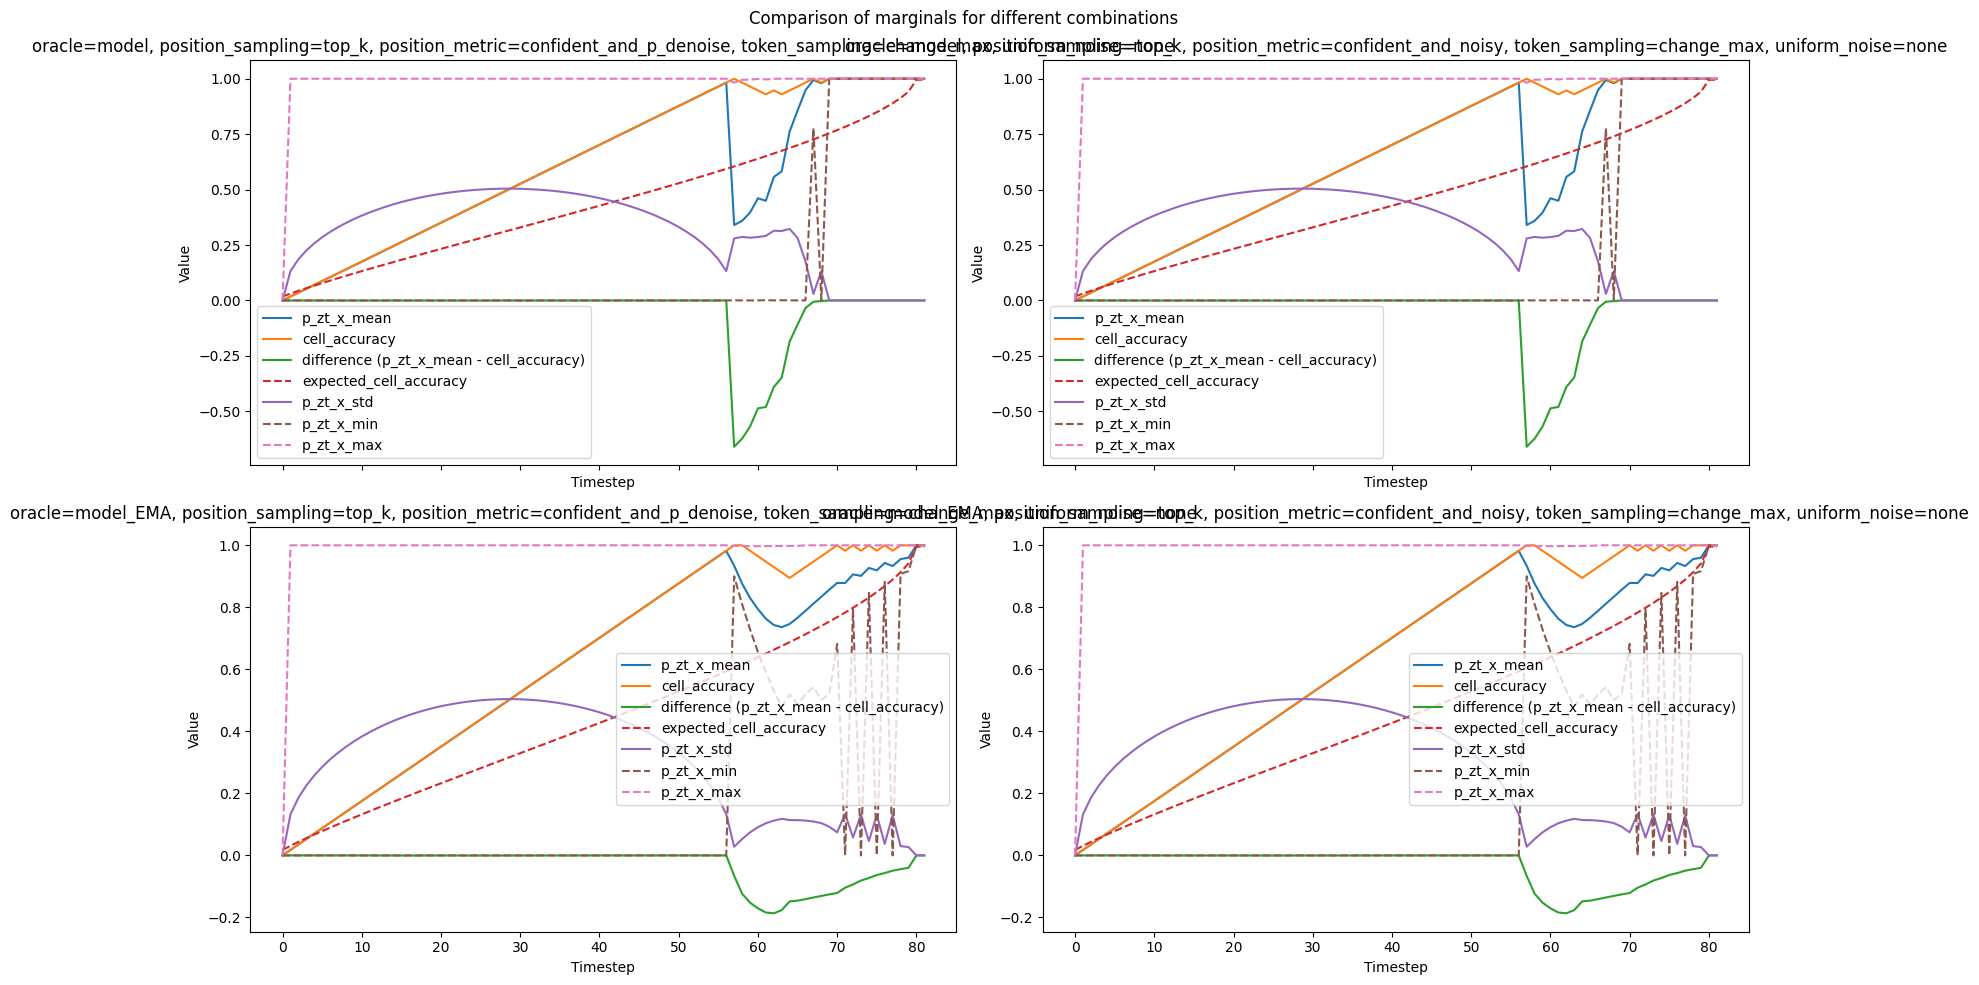

In [144]:
# Compare marginals of selected combinations

subplots_dim_0 = math.ceil(math.sqrt(num_selected_combinations))
subplots_dim_1 = math.ceil(num_selected_combinations / subplots_dim_0)
fig, axs = plt.subplots(subplots_dim_0, subplots_dim_1, figsize=(8 * subplots_dim_1, 5 * subplots_dim_0), sharex=True)
# sample_index = 0

for ax, idx in zip(axs.flatten(), range(num_selected_combinations)):
    selected_combination = selected_combinations[idx]
    marginals = marginals_dict[selected_combination]
    p_zt_x_mean = marginals['p_zt_x_mean'].cpu().numpy()  # shape: (num_samples, num_steps)
    p_zt_x_std = marginals['p_zt_x_std'].cpu().numpy()    # shape: (num_samples, num_steps)
    p_zt_x_min = marginals['p_zt_x_min'].cpu().numpy()    # shape: (num_samples, num_steps)
    p_zt_x_max = marginals['p_zt_x_max'].cpu().numpy()    # shape: (num_samples, num_steps)
    cell_accuracy = marginals['cell_accuracy'].cpu().numpy()  # shape: (num_samples, num_steps)
    expected_cell_accuracy = marginals['expected_cell_accuracy'].cpu().numpy()  # shape: (num_steps)
    difference = p_zt_x_mean - cell_accuracy

    ax.plot(p_zt_x_mean[sample_index], label='p_zt_x_mean')
    ax.plot(cell_accuracy[sample_index], label='cell_accuracy')
    ax.plot(difference[sample_index], label='difference (p_zt_x_mean - cell_accuracy)')
    ax.plot(expected_cell_accuracy, label='expected_cell_accuracy', linestyle='--')
    ax.plot(p_zt_x_std[sample_index], label='p_zt_x_std')
    ax.plot(p_zt_x_min[sample_index], label='p_zt_x_min', linestyle='--')
    ax.plot(p_zt_x_max[sample_index], label='p_zt_x_max', linestyle='--')
    ax.set_title(f"{', '.join([f'{key}={value}' for key, value in denoise_config_dict[selected_combination].items()])}")
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Value')
    ax.legend()
plt.suptitle('Comparison of marginals for different combinations')
plt.tight_layout()

Sample 1, cell accuracy at last step: 1.0
Sample 1, cell accuracy at last step: 1.0
Sample 1, cell accuracy at last step: 1.0
Sample 1, cell accuracy at last step: 1.0


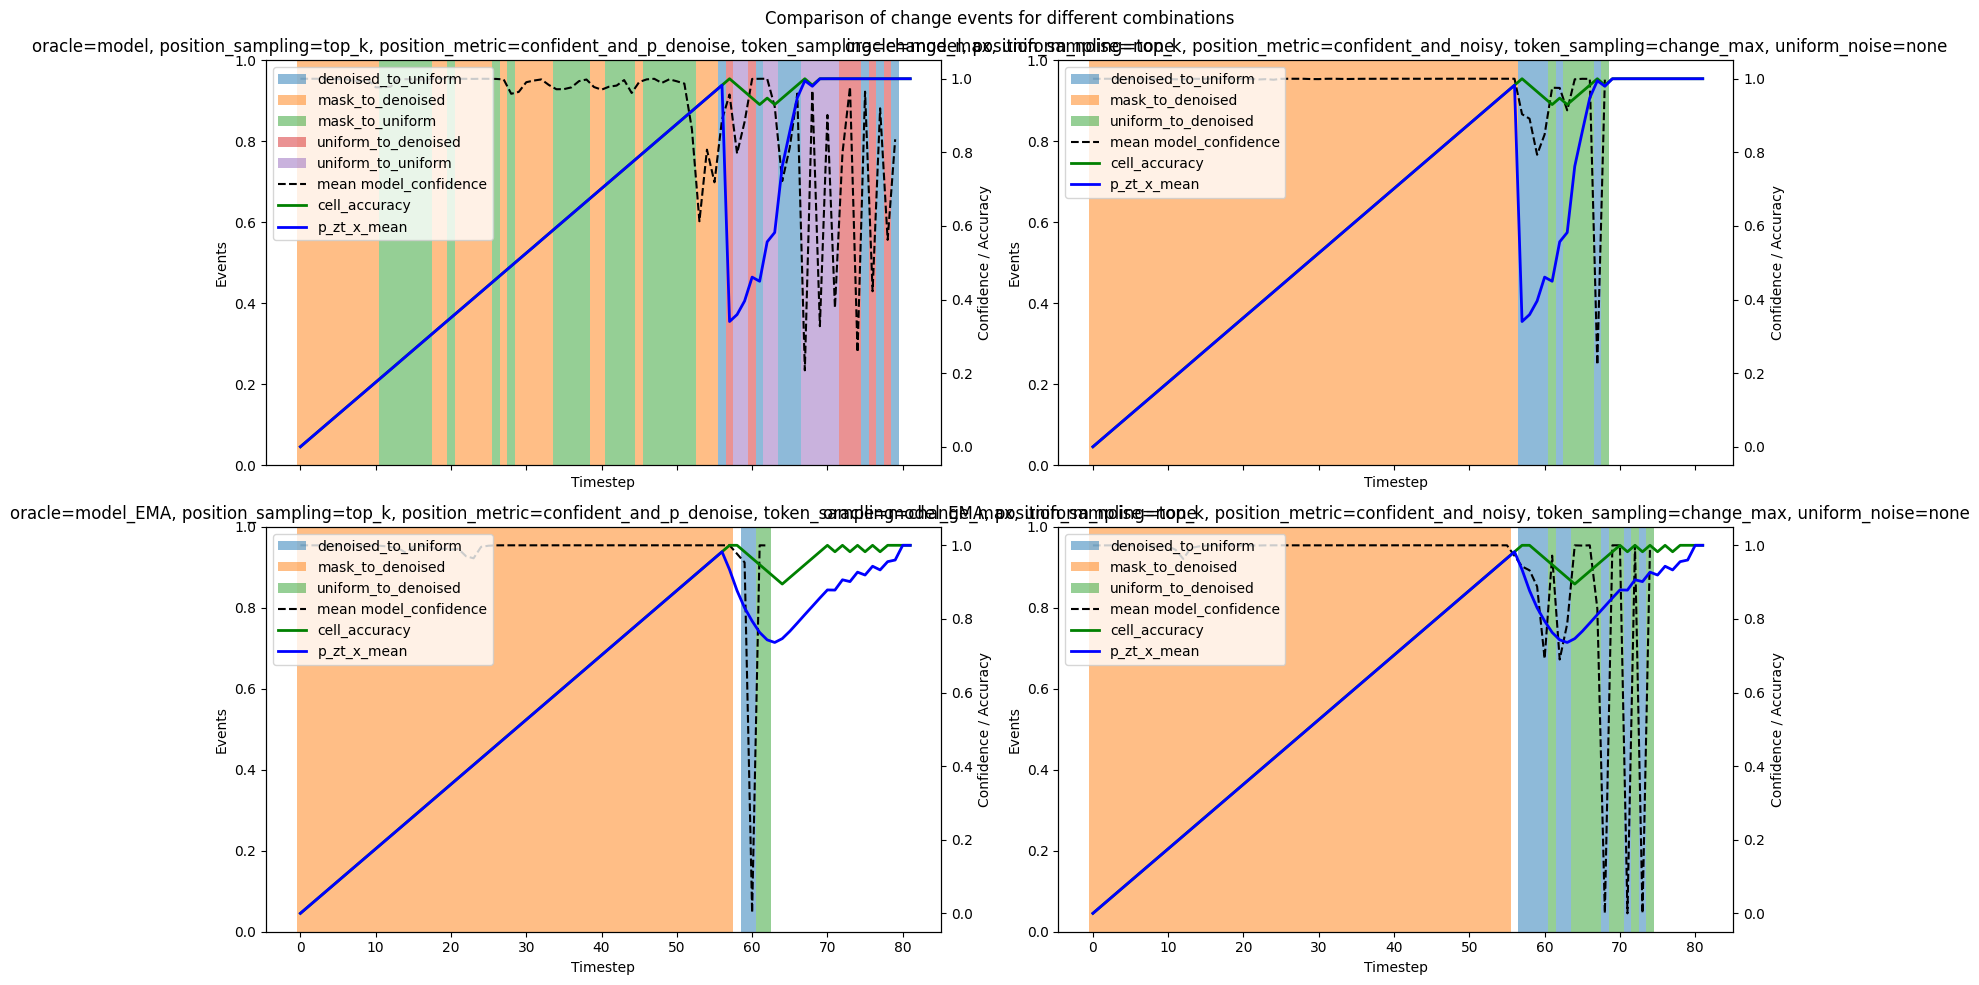

In [145]:
# Compare change events of selected combinations

subplots_dim_0 = math.ceil(math.sqrt(num_selected_combinations))
subplots_dim_1 = math.ceil(num_selected_combinations / subplots_dim_0)
fig, axs = plt.subplots(subplots_dim_0, subplots_dim_1, figsize=(8 * subplots_dim_1, 5 * subplots_dim_0), sharex=True)
# sample_index = 0

for ax, idx in zip(axs.flatten(), range(num_selected_combinations)):
    selected_combination = selected_combinations[idx]
    change_events_table = change_events_table_dict[selected_combination]
    marginals = marginals_dict[selected_combination]
    cell_accuracy = marginals['cell_accuracy'].cpu().numpy()
    p_zt_x_mean = marginals['p_zt_x_mean'].cpu().numpy()

    sample_events = change_events_table[change_events_table['sample'] == idx]

    event_counts = sample_events.groupby(['step', 'event_type']).size().unstack(fill_value=0)

    bottom = None
    for event_type in event_counts.columns:
        ax.bar(event_counts.index, event_counts[event_type], bottom=bottom, 
               alpha=0.5, width=1, label=event_type)
        if bottom is None:
            bottom = event_counts[event_type]
        else:
            bottom += event_counts[event_type]

    # Create a secondary y-axis for confidence and accuracy
    ax2 = ax.twinx()

    # Plot mean model_confidence per step
    mean_conf_before = sample_events.groupby('step')['model_confidence'].mean()
    ax2.plot(mean_conf_before.index, mean_conf_before.values, color='black', label='mean model_confidence', linestyle='--')

    # Plot cell_accuracy for this sample - now using actual timestep indices
    timesteps = range(len(cell_accuracy[sample_index]))
    ax2.plot(timesteps, cell_accuracy[sample_index], color='green', label='cell_accuracy', linewidth=2)
    ax2.plot(timesteps, p_zt_x_mean[sample_index], color='blue', label='p_zt_x_mean', linewidth=2)
    print(f"Sample {sample_index}, cell accuracy at last step: {cell_accuracy[sample_index, -1]}")

    ax.set_title(f"{', '.join([f'{key}={value}' for key, value in denoise_config_dict[selected_combination].items()])}")
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Events')
    ax2.set_ylabel('Confidence / Accuracy')

    # Combine legends from both axes
    handles1, labels1 = ax.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(handles1 + handles2, labels1 + labels2, loc='upper left')

plt.suptitle('Comparison of change events for different combinations')
plt.tight_layout()